In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_test = pd.read_csv('vehiculos_test.csv')
df_train = pd.read_csv('vehiculos_train.csv')

,index,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,num_asientos,num_puertas,problema_averia,id_problema_averia,fecha_averia,complejidad_reparacion,costo_reparacion,horas_reparacion,fecha_reparacion
0,0,Volkswagen,Passat,Blue,2015.0,Saloon,37723.0,2.0L,Automatic,Diesel,12690.0,5.0,4.0,Flat Tyres,0,2018-04-03,1,23.807,1.0,2018-04-03
1,1,Jaguar,XF,White,2014.0,Saloon,78000.0,2.2L,Automatic,Diesel,13490.0,5.0,4.0,Steering Wheel Shaking,0,2018-05-14,3,73.490,3.0,2018-05-14
2,2,Volkswagen,Polo,Orange,2010.0,Hatchback,44936.0,1.4L,Automatic,Petrol,NaN,5.0,5.0,Alternator Failing,0,2018-08-16,1,160.000,2.0,2018-08-16
3,3,Audi,S5,Black,2014.0,Coupe,29000.0,3.0L,Automatic,Petrol,22990.0,4.0,3.0,Steering Wheel Shaking,0,2018-07-24,1,42.990,1.0,2018-07-24
4,4,Toyota,Yaris,Black,2016.0,Hatchback,18037.0,1.33L,Manual,Petrol,9293.0,5.0,5.0,Electrical Issue,2,2018-05-04,1,28.586,0.5,2018-05-04


## Análisis Multivariado:
- Elija al menos dos pares de variables (no considere la variable target) y realice un análisis multivariable para cada par.
- Utilice visualizaciones adecuadas (por ejemplo, diagramas de dispersión, gráficos de barras).
- Explique cualquier relación observada entre los pares de variables analizados.


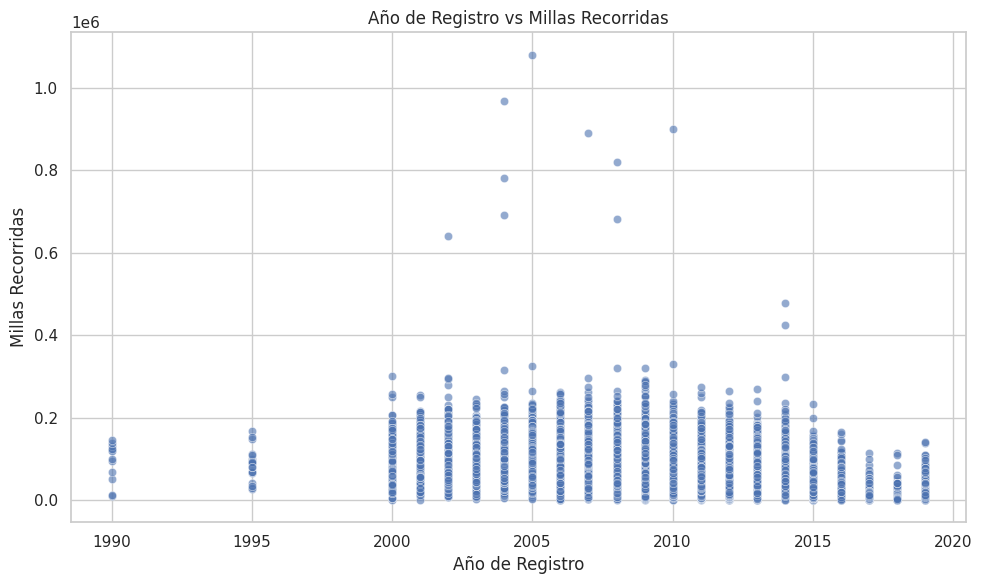

In [153]:
sns.set(style="whitegrid")

# ========== PAR 1: anio_registro vs millas_recorridas ==========
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_train_n, x='anio_registro', y='millas_recorridas', alpha=0.6)
plt.title('Año de Registro vs Millas Recorridas')
plt.xlabel('Año de Registro')
plt.ylabel('Millas Recorridas')
plt.tight_layout()
plt.show()

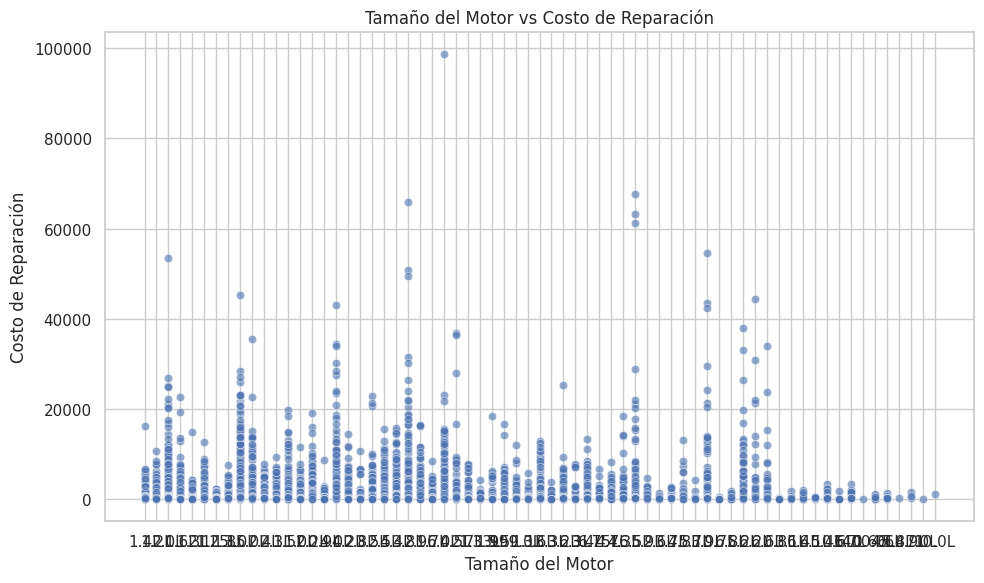

In [157]:
# ========== PAR 2: tamanio_motor vs costo_reparacion ==========
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_train_n, x='tamanio_motor', y='costo_reparacion', alpha=0.6)
plt.title('Tamaño del Motor vs Costo de Reparación')
plt.xlabel('Tamaño del Motor')
plt.ylabel('Costo de Reparación')
plt.tight_layout()
plt.show()


- Elija al menos dos variables de variables y realice un análisis multivariable entre las variables elegidas y la variable target.
- Utilice visualizaciones adecuadas (por ejemplo, diagramas de dispersión, gráficos de barras).
- Explique cualquier relación observada entre los pares de variables analizados.


In [169]:
df_train_n.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196429 entries, 0 to 196428
Data columns (total 20 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   marca                   196429 non-null  object 
 1   modelo                  196429 non-null  object 
 2   color                   196429 non-null  object 
 3   anio_registro           196429 non-null  float64
 4   tipo_vehiculo           196429 non-null  object 
 5   millas_recorridas       196429 non-null  float64
 6   tamanio_motor           196429 non-null  object 
 7   transmision             196429 non-null  object 
 8   tipo_combustible        196429 non-null  object 
 9   precio_vehiculo         196429 non-null  float64
 10  num_asientos            196429 non-null  float64
 11  num_puertas             196429 non-null  float64
 12  problema_averia         196429 non-null  object 
 13  id_problema_averia      196429 non-null  int64  
 14  fecha_averia        

Variables numéricas

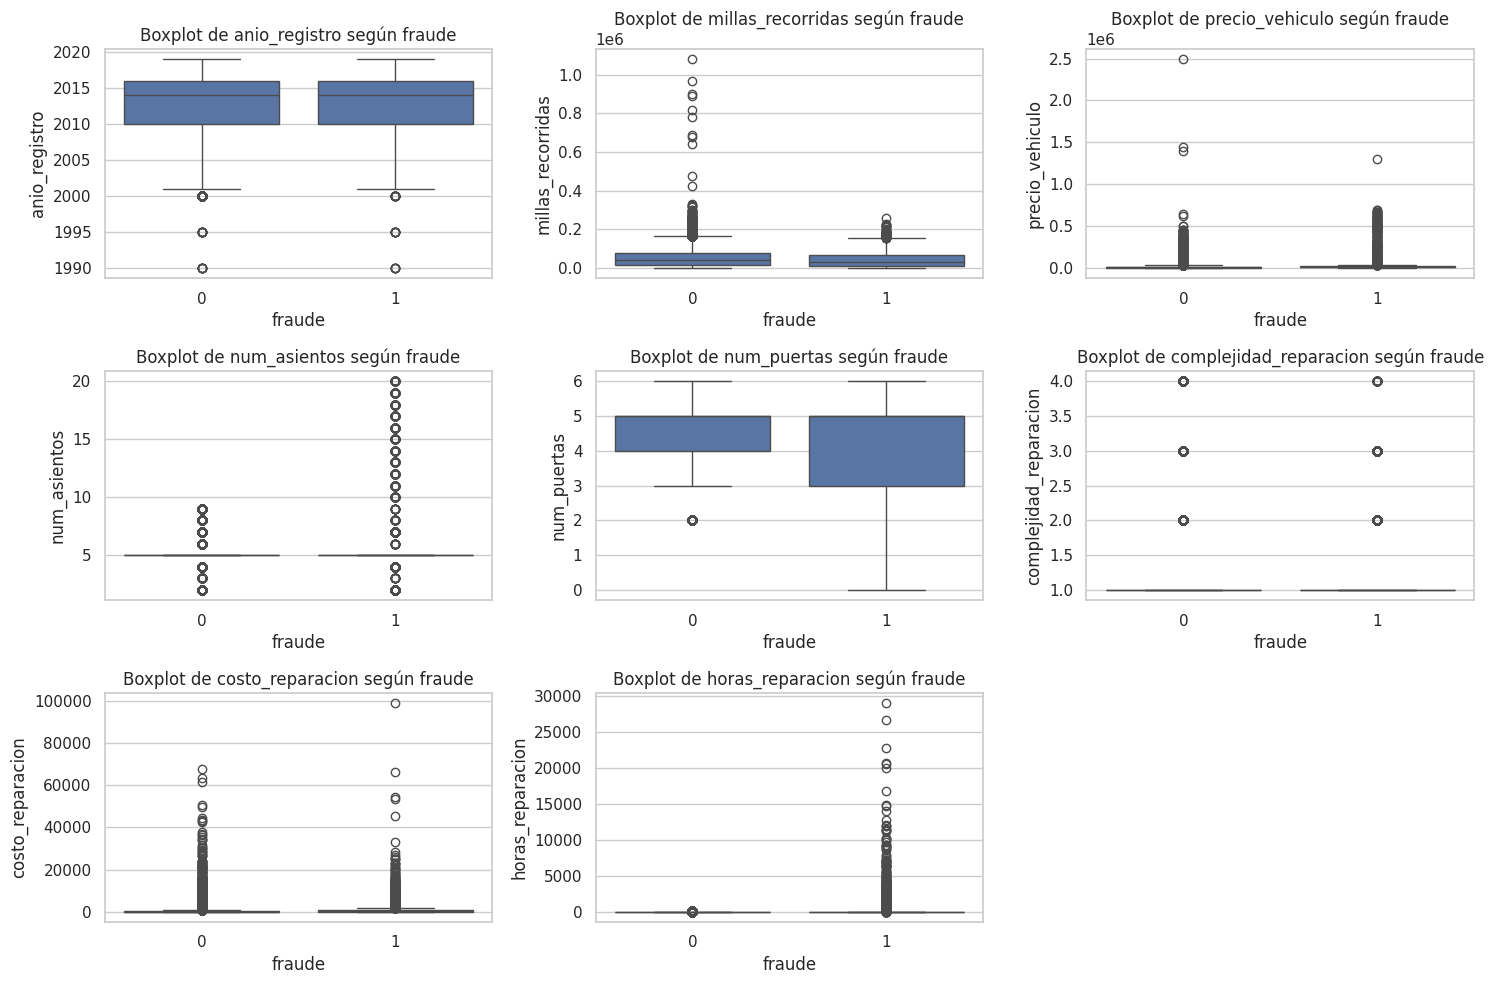

In [173]:
### Variables predictoras según la variable target

###### DIAGRAMAS DE CAJA
import matplotlib.pyplot as plt
import seaborn as sns
import math



df = df_train_n[['anio_registro','millas_recorridas','precio_vehiculo','num_asientos',
    'num_puertas','complejidad_reparacion','costo_reparacion','horas_reparacion','fraude']]

columnas = df.columns[:-1]
plt.figure(figsize=(15, 10))


for i, columna in enumerate(columnas, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x='fraude',y=df[columna], data=df)
    plt.title(f'Boxplot de {columna} según fraude')


plt.tight_layout()
plt.show()

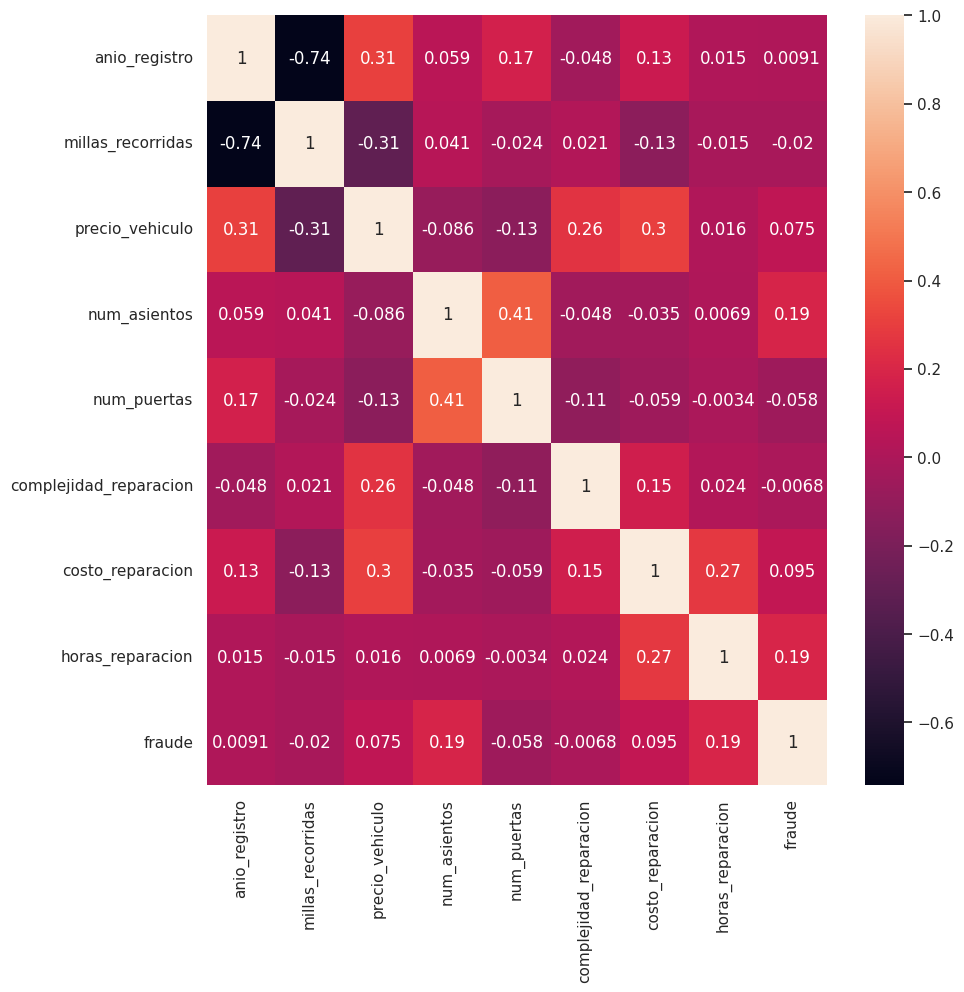

In [179]:
corr_matrix=df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix,annot=True)
plt.show()

Variables categóricas

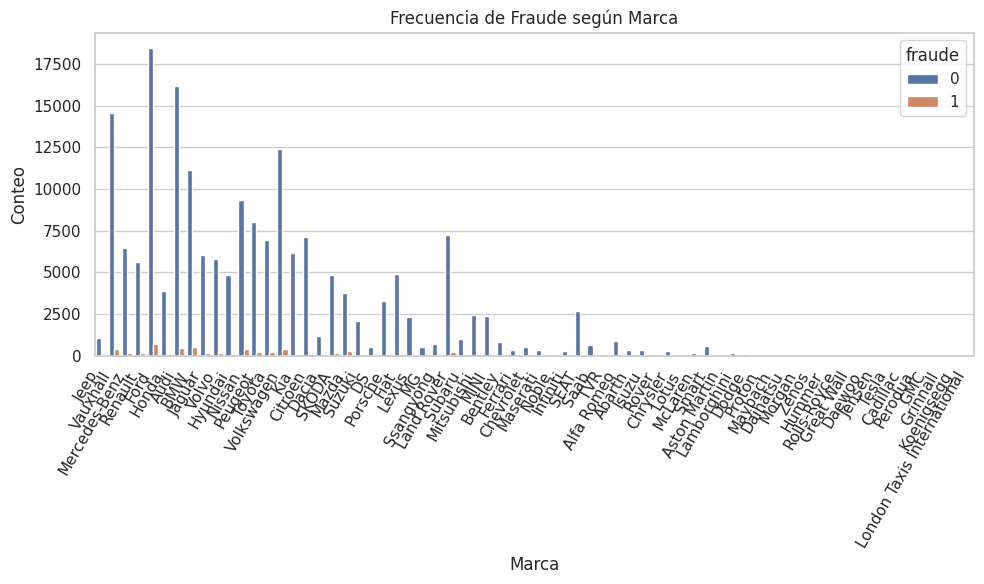

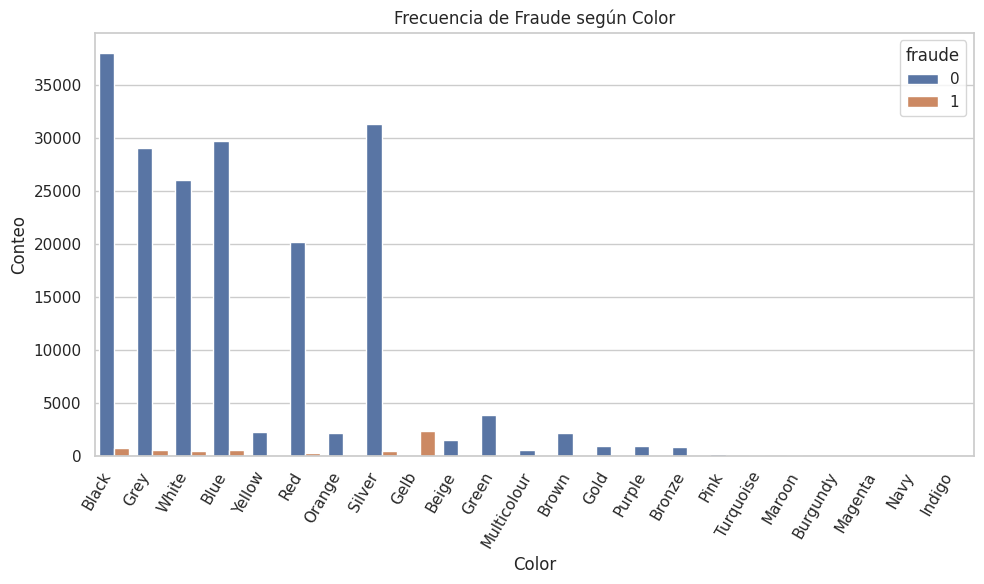

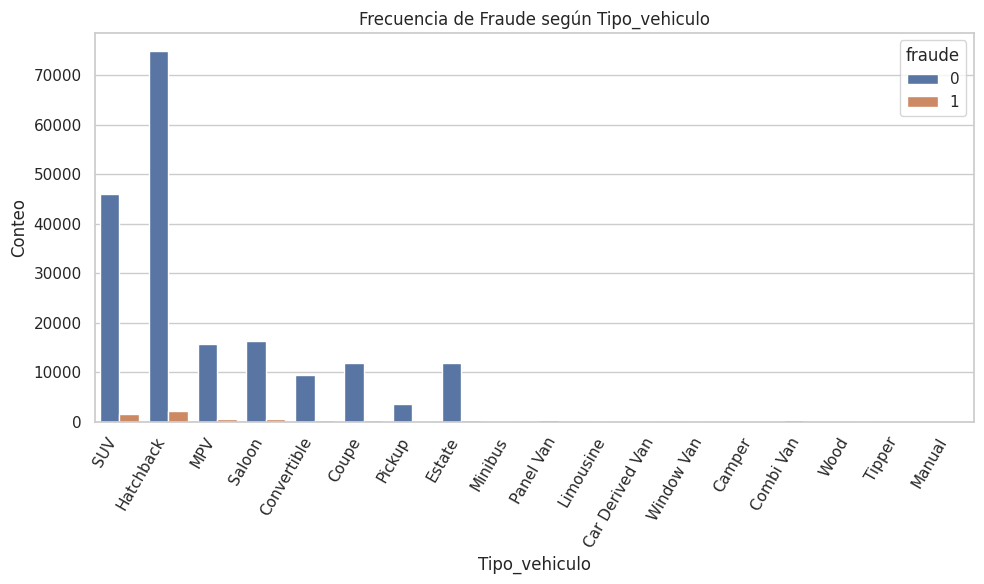

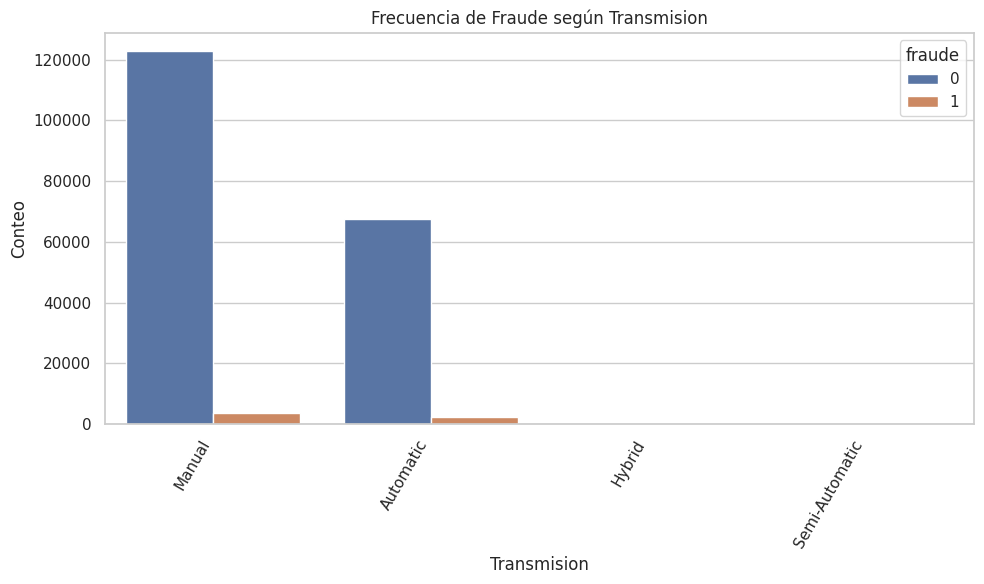

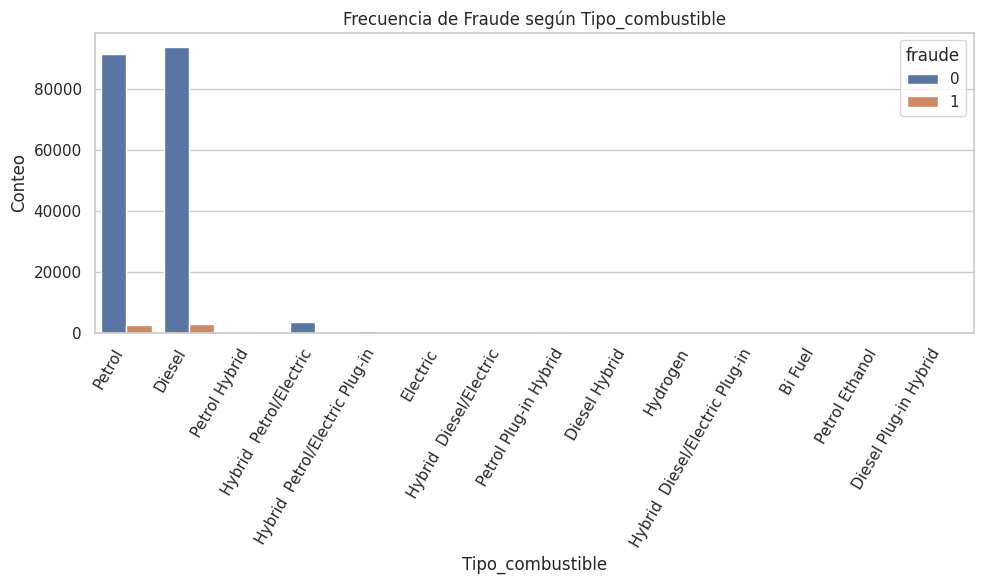

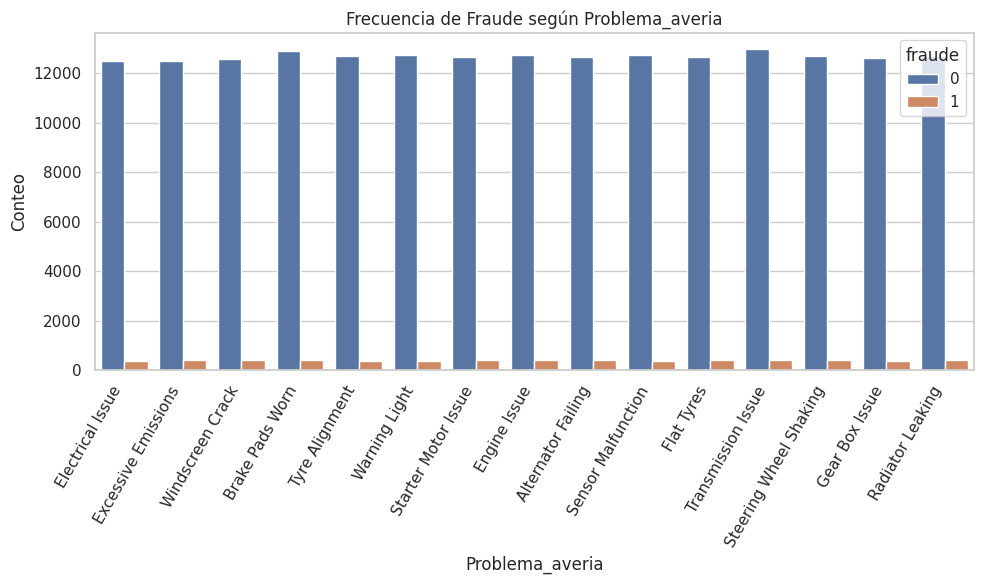

In [177]:
### Variables predictoras según la variable target

###### GRÁFICO DE BARRAS
import matplotlib.pyplot as plt
import seaborn as sns

variables_categoricas = ['marca', 'color', 'tipo_vehiculo','transmision', 'tipo_combustible', 'problema_averia']

# Graficar cada variable categórica vs. 'fraude'
for col in variables_categoricas:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_train_n, x=col, hue='fraude')
    plt.title(f'Frecuencia de Fraude según {col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Conteo')
    plt.xticks(rotation=60, ha='right')
    plt.tight_layout()
    plt.show()


## Implemente al menos 3 modelos de clasificación e intente superar al baseline compartido.
Para los 3 modelos utilice el mismo algoritmo de clasificación (elija uno aprendido en clases) con diferentes configuraciones. Distintas configuraciones pueden incluir distintos valores de hiperparámetros o técnicas de procesamiento de los datos de entrada. Para las distintas configuraciones puede considerar lo siguiente:
- Sus datos podrían ser estandarizados/normalizados o no.
- Puede definir alguna estrategia para codificar variables categóricas (puede utilizar One-hot-encoding, Target encoding, u otra estrategia).
- Identifique valores faltantes y defina una estrategia (de ser necesario) para la imputación de datos.
- Analice las variables categóricas y determine si es necesario tratar categorías poco frecuentes (por ejemplo, a veces agrupar categorías raras puede ser útil). Explique sus decisiones en el tratamiento de los datos.
- Detecte valores atípicos y defina una estrategia para tratarlos. Considere que eliminar los registros outliers (del set de entrenamiento) no es la única estrategia posible (puede considerar la regla del rango intercuartil, Local Outlier Factor, u otra estrategia). Explique sus decisiones en el tratamiento de los datos.



Definir el umbral mínimo de frecuencia para considerar una marca como representativa utlizando la diferencia entre la media y la desviaicon estandar.

In [3]:
umbral = 6000

In [ ]:
import pandas as pd

 # por ejemplo, marcas con menos de 50 apariciones se agrupan en "OTROS"

# Calcular la frecuencia de cada marca
frecuencias = df_train_n['marca'].value_counts()

NameError: name 'df_train_n' is not defined

In [458]:
frecuencias

marca
Ford                          19155
Audi                          16688
Vauxhall                      14973
Volkswagen                    12797
BMW                           11676
                              ...  
Zenos                             1
Jensen                            1
Grinnall                          1
Koenigsegg                        1
London Taxis International        1
Name: count, Length: 68, dtype: int64

In [480]:
# Create new column 'marca2' where rare brands are renamed to 'OTROS'
df_train_n['marca2'] = df_train_n['marca'].apply(lambda x: x if frecuencias[x] >= umbral else 'OTROS')

df_test_n['marca2'] = df_test_n['marca'].apply(lambda x: x if frecuencias[x] >= umbral else 'OTROS')

In [481]:
# Check the new distribution of brands
print("Train: ", df_train_n['marca2'].value_counts())
print("Test: ", df_test_n['marca2'].value_counts())

Train:  marca2
OTROS            62183
Ford             19155
Audi             16688
Vauxhall         14973
Volkswagen       12797
BMW              11676
Nissan            9726
Peugeot           8257
Land Rover        7469
Citroen           7242
Toyota            7167
Mercedes-Benz     6632
Kia               6290
Jaguar            6174
Name: count, dtype: int64
Test:  marca2
OTROS            6886
Ford             2216
Audi             1799
Vauxhall         1715
Volkswagen       1489
BMW              1254
Nissan           1033
Peugeot           865
Citroen           861
Land Rover        838
Toyota            834
Mercedes-Benz     705
Jaguar            667
Kia               664
Name: count, dtype: int64


In [482]:
# Aplicamos one-hot encoding a la columna 'marca2'
df_train_n_encoded = pd.get_dummies(df_train_n, columns=['marca2'])

# Si deseas que los valores codificados sean 0 y 1 (en número, no booleanos):
columnas_marca = [col for col in df_train_n_encoded.columns if col.startswith('marca2_')]

# Convertimos a numérico (0 y 1 en lugar de True/False)
for col in columnas_marca:
    df_train_n_encoded[col] = df_train_n_encoded[col].replace({True: 1, False: 0})
    df_train_n_encoded[col] = pd.to_numeric(df_train_n_encoded[col])

C:\Users\smithinator\AppData\Local\Temp\ipykernel_1228\1497364388.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train_n_encoded[col] = df_train_n_encoded[col].replace({True: 1, False: 0})


In [483]:
df_train_n_encoded.head()

,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,precio_vehiculo,...,marca2_Jaguar,marca2_Kia,marca2_Land Rover,marca2_Mercedes-Benz,marca2_Nissan,marca2_OTROS,marca2_Peugeot,marca2_Toyota,marca2_Vauxhall,marca2_Volkswagen
0,Jeep,Renegade,Black,2018.0,SUV,17.0,1.4L,Manual,Petrol,16000.0,...,0,0,0,0,0,1,0,0,0,0
1,Vauxhall,Insignia,Grey,2011.0,Hatchback,93000.0,NaN,Manual,Petrol,3995.0,...,0,0,0,0,0,0,0,0,1,0
2,Mercedes-Benz,GLC Class,White,2019.0,SUV,6879.0,2.0L,Automatic,Diesel,31498.0,...,0,0,0,1,0,0,0,0,0,0
3,Renault,NaN,NaN,2014.0,Hatchback,20669.0,1.2L,Manual,Petrol,6950.0,...,0,0,0,0,0,1,0,0,0,0
4,Ford,C-Max,NaN,2007.0,MPV,84786.0,1.6L,Manual,Petrol,NaN,...,0,0,0,0,0,0,0,0,0,0


In [484]:
df_train_n_encoded.columns

Index(['marca', 'modelo', 'color', 'anio_registro', 'tipo_vehiculo',
       'millas_recorridas', 'tamanio_motor', 'transmision', 'tipo_combustible',
       'precio_vehiculo', 'num_asientos', 'num_puertas', 'problema_averia',
       'id_problema_averia', 'fecha_averia', 'complejidad_reparacion',
       'costo_reparacion', 'horas_reparacion', 'fecha_reparacion', 'fraude',
       'marca2_Audi', 'marca2_BMW', 'marca2_Citroen', 'marca2_Ford',
       'marca2_Jaguar', 'marca2_Kia', 'marca2_Land Rover',
       'marca2_Mercedes-Benz', 'marca2_Nissan', 'marca2_OTROS',
       'marca2_Peugeot', 'marca2_Toyota', 'marca2_Vauxhall',
       'marca2_Volkswagen'],
      dtype='object')

In [512]:
# Aplicamos one-hot encoding a la columna 'marca2'
df_test_n_encoded = pd.get_dummies(df_test_n, columns=['marca2'])

# Si deseas que los valores codificados sean 0 y 1 (en número, no booleanos):
columnas_marca = [col for col in df_test_n_encoded.columns if col.startswith('marca2_')]

# Convertimos a numérico (0 y 1 en lugar de True/False)
for col in columnas_marca:
    df_test_n_encoded[col] = df_test_n_encoded[col].replace({True: 1, False: 0})
    df_test_n_encoded[col] = pd.to_numeric(df_test_n_encoded[col])



C:\Users\smithinator\AppData\Local\Temp\ipykernel_1228\2896934959.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test_n_encoded[col] = df_test_n_encoded[col].replace({True: 1, False: 0})


In [515]:
df_test_n_encoded.head()

,index,marca,modelo,color,anio_registro,tipo_vehiculo,millas_recorridas,tamanio_motor,transmision,tipo_combustible,...,marca2_Jaguar,marca2_Kia,marca2_Land Rover,marca2_Mercedes-Benz,marca2_Nissan,marca2_OTROS,marca2_Peugeot,marca2_Toyota,marca2_Vauxhall,marca2_Volkswagen
0,0,Volkswagen,Passat,Blue,2015.0,Saloon,37723.0,2.0L,Automatic,Diesel,...,0,0,0,0,0,0,0,0,0,1
1,1,Jaguar,XF,White,2014.0,Saloon,78000.0,2.2L,Automatic,Diesel,...,1,0,0,0,0,0,0,0,0,0
2,2,Volkswagen,Polo,Orange,2010.0,Hatchback,44936.0,1.4L,Automatic,Petrol,...,0,0,0,0,0,0,0,0,0,1
3,3,Audi,S5,Black,2014.0,Coupe,29000.0,3.0L,Automatic,Petrol,...,0,0,0,0,0,0,0,0,0,0
4,4,Toyota,Yaris,Black,2016.0,Hatchback,18037.0,1.33L,Manual,Petrol,...,0,0,0,0,0,0,0,1,0,0


In [485]:
predictor_vars = ['anio_registro','millas_recorridas','precio_vehiculo','num_asientos','num_puertas','complejidad_reparacion','costo_reparacion','horas_reparacion','marca2_Audi', 'marca2_BMW', 'marca2_Citroen', 'marca2_Ford',
       'marca2_Jaguar', 'marca2_Kia', 'marca2_Land Rover',
       'marca2_Mercedes-Benz', 'marca2_Nissan', 'marca2_OTROS',
       'marca2_Peugeot', 'marca2_Toyota', 'marca2_Vauxhall',
       'marca2_Volkswagen']
target_var = "fraude"

In [516]:
df_train_n_encoded[predictor_vars]
df_test_n_encoded[predictor_vars]

,anio_registro,millas_recorridas,precio_vehiculo,num_asientos,num_puertas,complejidad_reparacion,costo_reparacion,horas_reparacion,marca2_Audi,marca2_BMW,...,marca2_Jaguar,marca2_Kia,marca2_Land Rover,marca2_Mercedes-Benz,marca2_Nissan,marca2_OTROS,marca2_Peugeot,marca2_Toyota,marca2_Vauxhall,marca2_Volkswagen
0,2015.0,37723.0,12690.0,5.0,4.0,1,23.807,1.0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2014.0,78000.0,13490.0,5.0,4.0,3,73.490,3.0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,2010.0,44936.0,NaN,5.0,5.0,1,160.000,2.0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,2014.0,29000.0,22990.0,4.0,3.0,1,42.990,1.0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,2016.0,18037.0,9293.0,5.0,5.0,1,28.586,0.5,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21821,2014.0,43000.0,9795.0,7.0,5.0,1,25.877,1.0,0,0,...,0,0,0,0,0,0,1,0,0,0
21822,2013.0,39351.0,7990.0,5.0,5.0,1,43.995,2.0,0,0,...,0,0,0,0,0,0,0,1,0,0
21823,2009.0,100000.0,1800.0,5.0,5.0,1,40.900,2.0,0,0,...,0,0,0,0,0,1,0,0,0,0
21824,2012.0,69000.0,3995.0,5.0,5.0,1,119.900,2.0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [487]:
df_train_n_encoded.to_csv("vehiculos_train_n.csv")
df_test_n_encoded.to_csv("vehiculos_test_n.csv")

In [488]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [489]:
df_train_processed = pd.read_csv("./vehiculos_train_n.csv")

In [490]:
df_train_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196429 entries, 0 to 196428
Data columns (total 35 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Unnamed: 0              196429 non-null  int64  
 1   marca                   196429 non-null  object 
 2   modelo                  177768 non-null  object 
 3   color                   191581 non-null  object 
 4   anio_registro           191599 non-null  float64
 5   tipo_vehiculo           196429 non-null  object 
 6   millas_recorridas       193664 non-null  float64
 7   tamanio_motor           195482 non-null  object 
 8   transmision             196429 non-null  object 
 9   tipo_combustible        196429 non-null  object 
 10  precio_vehiculo         186867 non-null  float64
 11  num_asientos            196429 non-null  float64
 12  num_puertas             196429 non-null  float64
 13  problema_averia         196429 non-null  object 
 14  id_problema_averia  

In [491]:
X = df_train_processed[predictor_vars]
y = df_train_processed[target_var]

In [492]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=42)

In [493]:
print(f"{len(X_train)/len(X)*100}%")
print(f"{len(X_val)/len(X)*100}%")

79.99989818204033%
20.00010181795967%


In [494]:
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

In [495]:
y_train = y_train.values.reshape(-1, 1)
y_val = y_val.values.reshape(-1, 1)

In [496]:
X_scaler.fit(X_train)
y_scaler.fit(y_train)

MinMaxScaler()

In [497]:
X_train_scaled = X_scaler.transform(X_train)
X_val_scaled = X_scaler.transform(X_val)

In [498]:
y_train_scaled = y_scaler.transform(y_train)
y_val_scaled = y_scaler.transform(y_val)

## 1. Selección del Algoritmo
Hemos seleccionado **Random Forest** como nuestro algoritmo base por las siguientes razones:
- Excelente rendimiento en problemas de clasificación binaria
- Manejo robusto de datos desbalanceados (común en detección de fraude)
- Capacidad para manejar tanto variables numéricas como categóricas
- Menor tendencia al sobreajuste comparado con árboles individuales
- Proporciona importancia de características, útil para entender factores de fraude

In [499]:
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, truncnorm, randint
from sklearn.ensemble import RandomForestClassifier
import time

## 2. Configuración de los Modelos
Implementamos tres variantes del Random Forest con diferentes enfoques:

### Modelo 1: Random Forest con Configuración Básica

In [500]:
from sklearn.ensemble import RandomForestClassifier

In [501]:
rf1 = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

In [502]:
y_train_scaled = y_train_scaled.ravel()

In [503]:
rf1.fit(X_train_scaled, y_train_scaled)

RandomForestClassifier(random_state=42)

### Modelo 3: Random Forest con Optimización de Características

In [504]:
rf2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

In [505]:
rf2.fit(X_train_scaled, y_train_scaled)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, random_state=42)

**Justificación**: Optimizado para seleccionar características relevantes y reducir ruido en la predicción.

### Modelo 3: Random Forest con Optimización de Características

In [506]:
# Configuration with feature selection
rf3 = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    min_samples_split=3,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)

In [507]:
rf3.fit(X_train_scaled, y_train_scaled)

RandomForestClassifier(max_depth=15, min_samples_leaf=2, min_samples_split=3,
                       n_estimators=150, random_state=42)

**Justificación**: Optimizado para seleccionar características relevantes y reducir ruido en la predicción.

## Evalúe y compare todos los modelos.
Interprete los resultados y concluya cuál modelo es el mejor. Puede considerar más de una métrica de evaluación para su conclusión.


## 3. Proceso de Evaluación
Implementamos un proceso de evaluación robusto:

In [508]:
from sklearn.metrics import balanced_accuracy_score, classification_report

In [509]:
models = [rf1, rf2, rf3]
results = {}

In [510]:
for i, model in enumerate(models, 1):
    print(f"\nEvaluando Modelo {i}:")
    print("-" * 50)
    
    # Realizar predicciones con datos escalados
    y_pred_scaled = model.predict(X_val_scaled)
    
    # Calcular la precisión balanceada
    balanced_acc = balanced_accuracy_score(y_val, y_pred_scaled)
    
    # Almacenar resultados en el diccionario
    results[f"Model_{i}"] = {
        "balanced_accuracy": balanced_acc,
        "classification_report": classification_report(y_val, y_pred_scaled)
    }
    
    # Imprimir resultados
    print(f"Precisión Balanceada: {balanced_acc:.4f}")
    print("\nInforme de Clasificación:")
    print(classification_report(y_val, y_pred_scaled))

# Encontrar el mejor modelo
best_model_name = max(results, key=lambda k: results[k]["balanced_accuracy"])
print(f"\nMejor Modelo: {best_model_name}")
print(f"Mejor Precisión Balanceada: {results[best_model_name]['balanced_accuracy']:.4f}")


Evaluando Modelo 1:
--------------------------------------------------
Precisión Balanceada: 0.7208

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     38100
           1       0.99      0.44      0.61      1186

    accuracy                           0.98     39286
   macro avg       0.99      0.72      0.80     39286
weighted avg       0.98      0.98      0.98     39286


Evaluando Modelo 2:
--------------------------------------------------
Precisión Balanceada: 0.7330

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97     38100
           1       0.25      0.51      0.34      1186

    accuracy                           0.94     39286
   macro avg       0.62      0.73      0.65     39286
weighted avg       0.96      0.94      0.95     39286


Evaluando Modelo 3:
--------------------------------------------------
Precisión Balancea

Encontramos el mejor modelo

In [511]:
best_model_name = max(results, key=lambda k: results[k]["balanced_accuracy"])
print(f"\nBest Model: {best_model_name}")
print(f"Best Balanced Accuracy: {results[best_model_name]['balanced_accuracy']:.4f}")


Best Model: Model_2
Best Balanced Accuracy: 0.7330


In [ ]:
df_test = pd.read_csv("./vehiculos_test.csv")

X_test = df_test[predictor_vars]

NameError: name 'predictor_vars' is not defined

In [ ]:
y_test_pred = models[best_model_name].predict(X_test)

In [ ]:
y_test_pred.to_csv("vehiculos_test_preds.csv")